# Regresión Lineal

En este ejercicio se explican los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la Ciberseguridad.

## Predicción del Coste de un Incidente de Seguridad

El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.


# 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

%matplotlib inline

# 1. Generación del Dataset

In [2]:
np.random.seed(42) # Garantiza que los datos sean siempre los mismos para reproducibilidad
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)


print(f"Ejemplos de entrenamiento (m): {len(x)}")
print(f"Rango de x: [{x.min():.3f}, {x.max():.3f}]")
print(f"Rango de y: [{y.min():.3f}, {y.max():.3f}]")
print(f"\nParámetros reales del dataset: θ₀=4, θ₁=3")

Ejemplos de entrenamiento (m): 100
Rango de x: [0.011, 1.974]
Rango de y: [3.238, 11.044]

Parámetros reales del dataset: θ₀=4, θ₁=3


# 2. Visualización del Conjunto de Datos

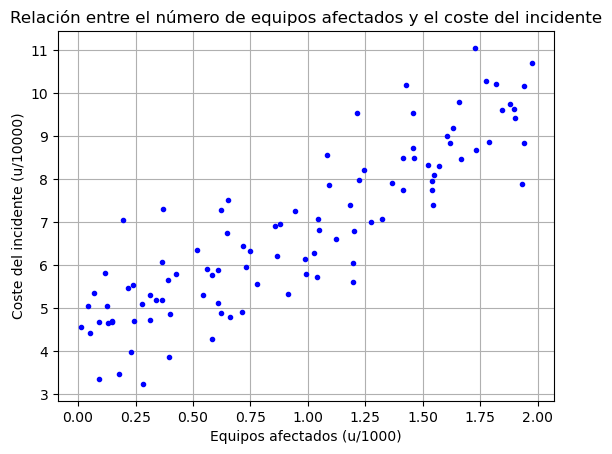

In [7]:
plt.plot(x, y, "b.")
plt.xlabel("Equipos afectados (u/1000)")
plt.ylabel("Coste del incidente (u/10000)")
plt.title("Relación entre el número de equipos afectados y el coste del incidente")
plt.grid(True)
plt.show()

Se refleja una tendencia lineal positiva clara: a más equipos afectados, mayor coste del incidente. La dispersión de los puntos refleja el ruido gaussiano, es decir, la variabilidad de los datos reales. En la práctica, dos incidentes con el mismo número de equipos nunca costarán exactamente lo mismo. Las unidades están normalizadas y se escalan con el paso siguiente

# 3. Modificación del Conjunto de Datos

In [8]:
data = {'n_equipos_afectados': x.flatten(), 'coste_incidente': y.flatten()}
df = pd.DataFrame(data)
print(df.head())

   n_equipos_afectados  coste_incidente
0             0.749080         6.334288
1             1.901429         9.405278
2             1.463988         8.483724
3             1.197317         5.604382
4             0.312037         4.716440


In [9]:
df['n_equipos_afectados'] = (df['n_equipos_afectados'] * 1000).astype(int)
df['coste_incidente'] = (df['coste_incidente'] * 10000).astype(int)
df.head() 

,n_equipos_afectados,coste_incidente
0,749,63342
1,1901,94052
2,1463,84837
3,1197,56043
4,312,47164


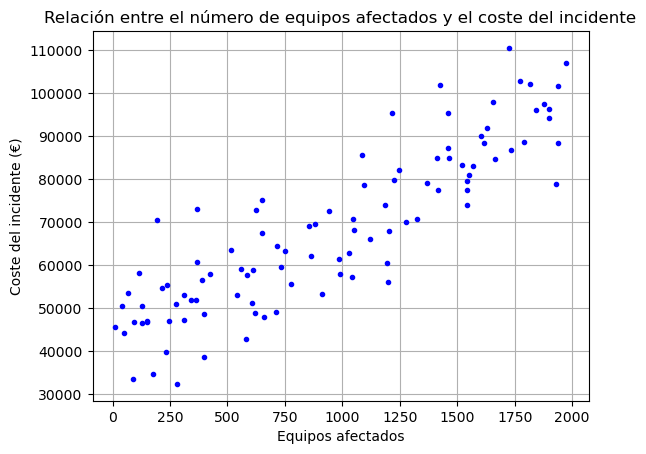

In [10]:
plt.plot(df['n_equipos_afectados'], df['coste_incidente'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente (€)")
plt.title("Relación entre el número de equipos afectados y el coste del incidente")
plt.grid(True)
plt.show()

Se observa que se tiene la misma tendencia que el gráfico anterior pero ahora en unidades reales: entre 0 y ~2.000 equipos afectados con costes de entre 30.000€ y 110.000€. La variabilidad entre incidentes con un número similar de equipos refleja que factores no capturados por el modelo como el tipo de ataque o la criticidad de los sistemas también influyen en el coste final.

# 4. Construcción del Modelo

In [11]:
lin_reg = LinearRegression()
lin_reg.fit(df[['n_equipos_afectados']], df['coste_incidente'])

print("θ₀ (bias):", round(lin_reg.intercept_)) # Coste base de cualquier incidente, independientemente del número de equipos afectados
print("θ₁ (pendiente):", round(lin_reg.coef_[0], 2)) # Coste adicional por cada equipo afectado. 

θ₀ (bias): 42163
θ₁ (pendiente): 27.7


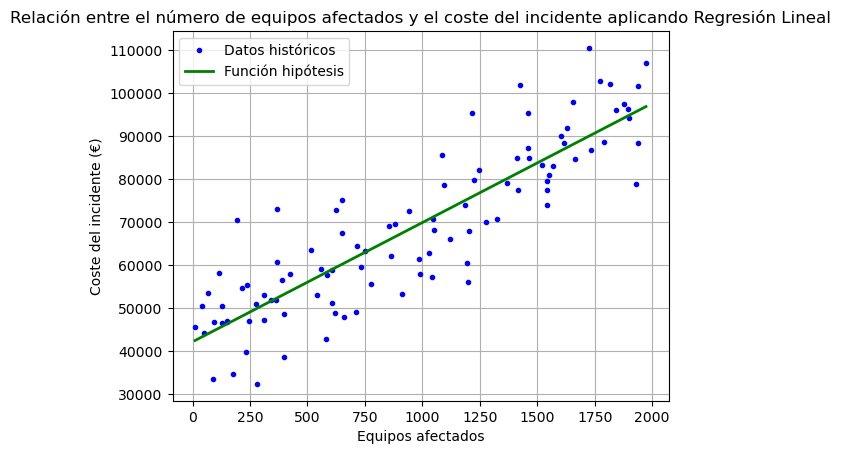

In [14]:
# Se generan solo dos puntos (mínimo y máximo) para trazar la recta,
# ya que dos puntos son suficientes para definir una línea
X_min_max = pd.DataFrame(
    [[df['n_equipos_afectados'].min()], [df['n_equipos_afectados'].max()]],
    columns=['n_equipos_afectados']
)
y_pred_line = lin_reg.predict(X_min_max)

plt.plot(df['n_equipos_afectados'], df['coste_incidente'], "b.", label="Datos históricos")
plt.plot(X_min_max, y_pred_line, "g-", linewidth=2, label="Función hipótesis")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente (€)")
plt.title("Relación entre el número de equipos afectados y el coste del incidente aplicando Regresión Lineal")
plt.legend()
plt.grid(True)
plt.show()


La línea verde es la función hipótesis $H(x) = θ₀ + θ₁x$ ajustada por el modelo. Representa la tendencia central de los datos y es la recta que minimiza el error cuadrático medio entre cada punto azul y su valor predicho. Los puntos se distribuyen a ambos lados sin un patrón claro, lo que indica un buen ajuste.

# 5. Predicción de Nuevos Ejemplos

In [27]:
x_pred = pd.DataFrame([[1500]], columns=['n_equipos_afectados'])
y_pred = lin_reg.predict(x_pred)

print("Predicción del coste:", int(y_pred[0]), "€")

Predicción del coste: 83716 €


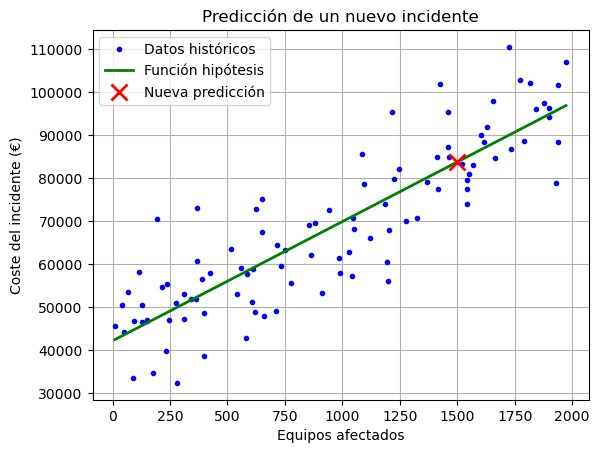

In [28]:
plt.plot(df['n_equipos_afectados'], df['coste_incidente'], "b.", label="Datos históricos")
plt.plot(X_min_max, y_pred_line, "g-", linewidth=2, label="Función hipótesis")
plt.plot(x_pred, y_pred, "rx", markersize=12, markeredgewidth=2, label="Nueva predicción")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente (€)")
plt.title("Predicción de un nuevo incidente")
plt.legend()
plt.grid(True)
plt.show()

A pesar de que la predicción cae exactamente sobre la recta los puntos azules cercanos a $x=1.500$ muestran que en la realidad un incidente similar podría costar entre 70.000€ y 102.000€, diferencia explicada por factores externos no capturados en el modelo.